# MovieLens-1M: a quick look at the data

The dataset every model here is trained and tested on, in a few numbers and charts:

1. how big it is (users, movies, ratings)
2. how ratings are spread over users, movies, stars and genres
3. how it is split into training, validation and test (`genrec.data`)

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.ticker import StrMethodFormatter

from genrec.data import Dataset, history, sample_test_users
from genrec.paths import ML1M_DIR

BLUE = "#2a78d6"                                  # one series per chart, so one color
INK, INK_2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_2, "axes.titlecolor": INK, "axes.titlesize": 12,
    "axes.titleweight": "bold", "axes.titlelocation": "left", "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 10,
})
THOUSANDS = StrMethodFormatter("{x:,.0f}")


def bars(ax, labels, values, title, ylabel):
    """Bar chart with each value written on its bar."""
    b = ax.bar(labels, values, color=BLUE, width=0.6)
    ax.bar_label(b, labels=[f"{v:,}" for v in values], padding=3, color=INK, fontsize=9)
    ax.set(title=title, ylabel=ylabel)
    ax.yaxis.set_major_formatter(THOUSANDS)
    ax.grid(axis="x", visible=False)
    ax.margins(y=0.12)


ds = Dataset.load(ML1M_DIR)
per_user = ds.sequences.map(len)
per_movie = ds.ratings.MovieID.value_counts()

## 1. Size

In [2]:
summary = pd.Series({
    "users": len(ds.sequences),
    "movies in the catalogue": len(ds.movies),
    "movies with at least one rating": ds.index.n_cols - 1,
    "ratings": len(ds.ratings),
    "ratings per user (median)": round(per_user.median()),
    "ratings per movie (median)": round(per_movie.median()),
    "filled share of the user x movie matrix": f"{len(ds.ratings) / (len(ds.sequences) * (ds.index.n_cols - 1)):.1%}",
}, name="MovieLens-1M")
summary.to_frame()

,MovieLens-1M
users,6040
movies in the catalogue,3883
movies with at least one rating,3706
ratings,1000209
ratings per user (median),96
ratings per movie (median),124
filled share of the user x movie matrix,4.5%


## 2. Distributions

Every user rated at least 20 movies (MovieLens only kept those), but a few rated hundreds or thousands - the
x-axes are logarithmic so both ends are visible. Movies are just as uneven: a few hundred blockbusters collect most
ratings while many movies have only a handful.

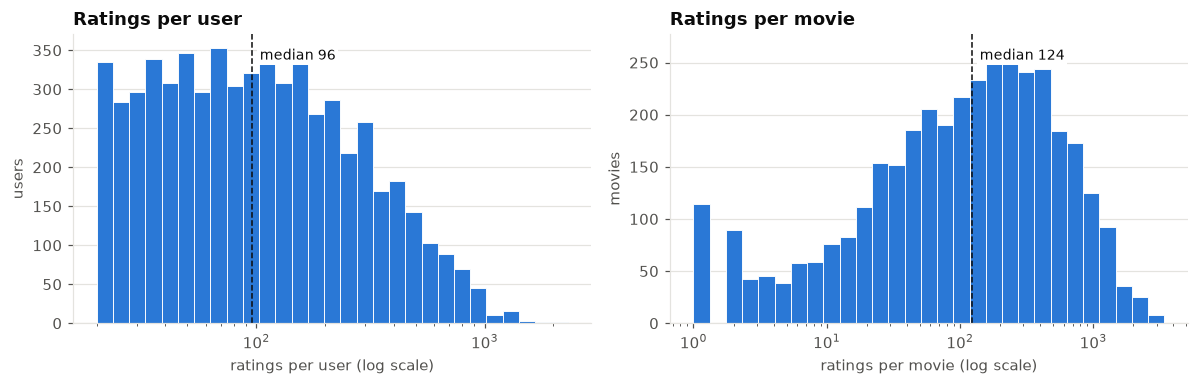

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, counts, what in [(axes[0], per_user, "user"), (axes[1], per_movie, "movie")]:
    ax.hist(counts, bins=np.geomspace(counts.min(), counts.max(), 30), color=BLUE, edgecolor="white", linewidth=0.6)
    ax.set_xscale("log")
    ax.axvline(counts.median(), color=INK, linewidth=1, linestyle="--")
    ax.annotate(f"median {counts.median():.0f}", (counts.median(), 0.95), xycoords=("data", "axes fraction"),
                xytext=(5, 0), textcoords="offset points", color=INK, fontsize=9, va="top",
                bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.5})
    ax.set(title=f"Ratings per {what}", xlabel=f"ratings per {what} (log scale)", ylabel=f"{what}s")
    ax.grid(axis="x", visible=False)
fig.tight_layout()

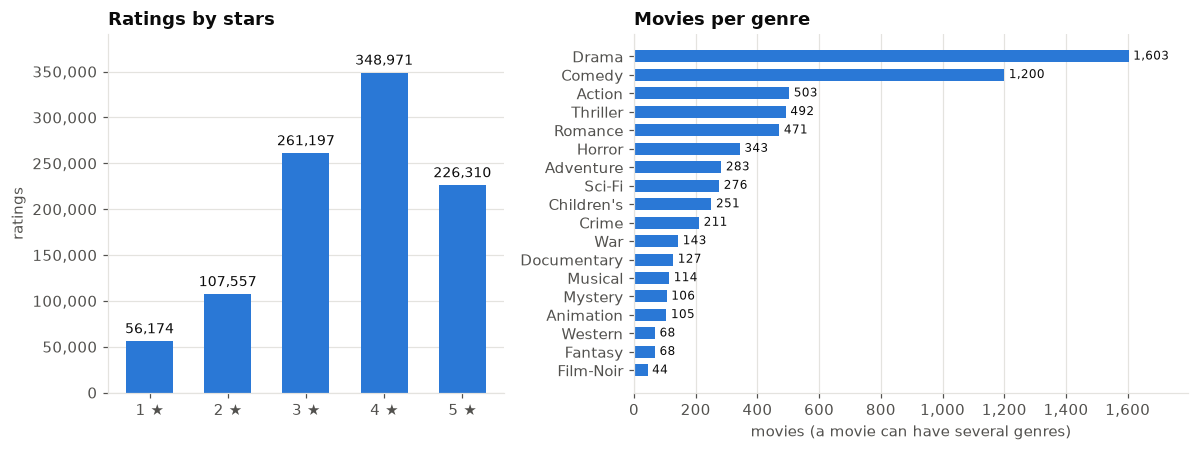

In [4]:
stars = ds.ratings.Rating.value_counts().sort_index()
genres = ds.movies.Genres.str.split("|").explode().loc[lambda g: g != ""].value_counts().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1, 1.4]})
bars(axes[0], [f"{s} ★" for s in stars.index], stars.tolist(), "Ratings by stars", "ratings")
b = axes[1].barh(genres.index, genres.values, color=BLUE, height=0.65)
axes[1].bar_label(b, labels=[f"{v:,}" for v in genres.values], padding=3, color=INK, fontsize=8)
axes[1].set(title="Movies per genre", xlabel="movies (a movie can have several genres)")
axes[1].xaxis.set_major_formatter(THOUSANDS)
axes[1].grid(axis="y", visible=False)
axes[1].margins(x=0.12)
fig.tight_layout()

## 3. Training and test split

Each user's ratings are put in time order, then split **leave-last-out**: the last rating is the **test** target,
the one before it is the **validation** target (to pick epochs / checkpoints), and everything earlier is
**training** data. So every user is in training, and the test asks: *given what you watched so far, what's next?*

Scoring every model on all 6,040 users would be slow for the LLM, so the test uses the **same 1,000 randomly
sampled users** for every model (`sample_test_users`).

In [5]:
test_users = sample_test_users(ds.users)
split = pd.DataFrame({
    "users": [len(ds.users), len(ds.users), len(test_users)],
    "ratings": [sum(len(history(s, "val")) for s in ds.sequences), len(ds.users), len(test_users)],
}, index=["training", "validation", "test"])
split["ratings per user"] = (split["ratings"] / split["users"]).round(1)
split

,users,ratings,ratings per user
training,6040,988129,163.6
validation,6040,6040,1.0
test,1000,1000,1.0


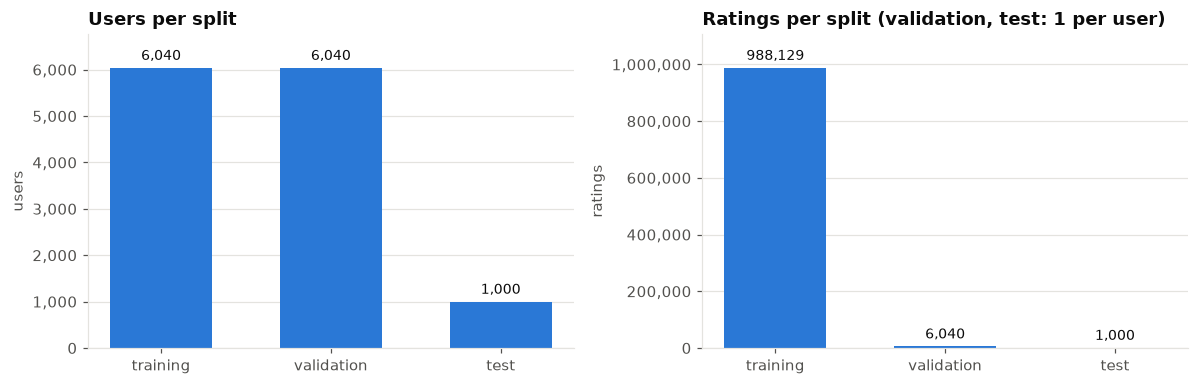

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
bars(axes[0], split.index, split["users"].tolist(), "Users per split", "users")
bars(axes[1], split.index, split["ratings"].tolist(), "Ratings per split (validation, test: 1 per user)", "ratings")
fig.tight_layout()